In [98]:
import pandas as pd
import pandasql as psql
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

In [72]:
# Load data sets
# Load your CSVs into DataFrames
users = pd.read_csv("takehome_users.csv", encoding="latin1")
engagement = pd.read_csv("takehome_user_engagement.csv", encoding="latin1")

# Make sure timestamps are datetime
engagement['time_stamp'] = pd.to_datetime(engagement['time_stamp'])

# Sort for safety
engagement = engagement.sort_values(['user_id', 'time_stamp'])

# Group by user_id and check rolling 7-day windows
adopted_users = []

for uid, df in engagement.groupby('user_id'):
    # Take distinct login days
    days = df['time_stamp'].dt.floor('D').drop_duplicates().sort_values()
    
    # Check 7-day rolling window
    adopted = False
    for i in range(len(days) - 2):  # need at least 3 days
        if (days.iloc[i+2] - days.iloc[i]).days <= 7:
            adopted = True
            break
    adopted_users.append((uid, adopted))

# Make into DataFrame
adopted_df = pd.DataFrame(adopted_users, columns=['user_id', 'adopted_user'])

# Merge back into users table
users = users.merge(adopted_df, how='left', left_on='object_id', right_on='user_id')
users['adopted_user'] = users['adopted_user'].fillna(False)

/var/folders/cq/gp4mmh_532d1t3573lxjzj5w0000gp/T/ipykernel_89093/2337074380.py:32: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  users['adopted_user'] = users['adopted_user'].fillna(False)


In [73]:
users.head()

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,user_id,adopted_user
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0,1.0,False
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0,2.0,True
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0,3.0,False
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0,4.0,False
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0,5.0,False


In [74]:
users.describe().T

,count,mean,std,min,25%,50%,75%,max
object_id,12000.0,6.000500e+03,3.464246e+03,1.000000e+00,3.000750e+03,6.000500e+03,9.000250e+03,1.200000e+04
last_session_creation_time,8823.0,1.379279e+09,1.953116e+07,1.338452e+09,1.363195e+09,1.382888e+09,1.398443e+09,1.402067e+09
opted_in_to_mailing_list,12000.0,2.495000e-01,4.327417e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
enabled_for_marketing_drip,12000.0,1.493333e-01,3.564316e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
org_id,12000.0,1.418846e+02,1.240567e+02,0.000000e+00,2.900000e+01,1.080000e+02,2.382500e+02,4.160000e+02
invited_by_user_id,6417.0,5.962957e+03,3.383762e+03,3.000000e+00,3.058000e+03,5.954000e+03,8.817000e+03,1.199900e+04
user_id,8823.0,6.019822e+03,3.464251e+03,1.000000e+00,3.017500e+03,6.034000e+03,9.029500e+03,1.200000e+04


In [75]:
# Drop columns we don't need
users = users.drop(columns= ['creation_time','name','email','last_session_creation_time',
                             'invited_by_user_id','user_id'])
users.head()

,object_id,creation_source,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,adopted_user
0,1,GUEST_INVITE,1,0,11,False
1,2,ORG_INVITE,0,0,1,True
2,3,ORG_INVITE,0,0,94,False
3,4,GUEST_INVITE,0,0,1,False
4,5,GUEST_INVITE,0,0,193,False


In [76]:
# Check for null values
users.isna().sum()

object_id                     0
creation_source               0
opted_in_to_mailing_list      0
enabled_for_marketing_drip    0
org_id                        0
adopted_user                  0
dtype: int64

In [77]:
# Check for duplicates
users.duplicated().sum()

np.int64(0)

In [78]:
# Drop object_id
users = users.drop(columns=['object_id'])

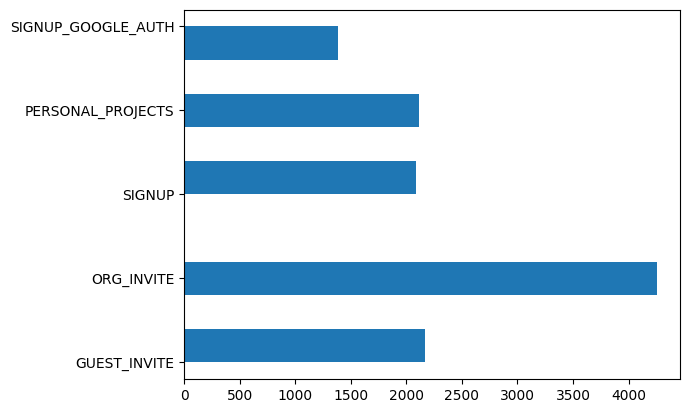

In [79]:
# Check out categorical variables
plt.hist(users.creation_source,orientation='horizontal');

In [80]:
users.org_id.value_counts()

org_id
0      319
1      233
2      201
3      168
4      159
      ... 
396      9
397      8
400      8
386      7
416      2
Name: count, Length: 417, dtype: int64

There are 417 org_ids. Too many categories, let's drop.

In [81]:
users = users .drop(columns=['org_id'])

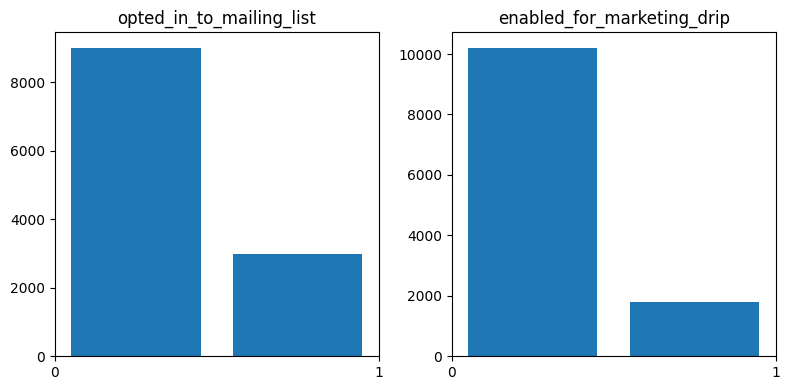

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

cols = ['opted_in_to_mailing_list', 'enabled_for_marketing_drip']

for ax, col in zip(axes, cols):
    ax.hist(users[col], bins=2, rwidth=0.8)
    ax.set_title(col)
    ax.set_xticks([0, 1])

plt.tight_layout()
plt.show()

In [83]:
users.adopted_user.value_counts()

adopted_user
False    10344
True      1656
Name: count, dtype: int64

In [84]:
1656/(10344+1656)

0.138

In [85]:
users.dtypes

creation_source               object
opted_in_to_mailing_list       int64
enabled_for_marketing_drip     int64
adopted_user                    bool
dtype: object

In [86]:
# One hot encode creation_source
dummies = pd.get_dummies(users['creation_source'])

# Join back to the main dataframe (drop original if you don’t want it)
users_encoded = pd.concat([users.drop(columns=['creation_source']), dummies], axis=1)

users_encoded.head()

,opted_in_to_mailing_list,enabled_for_marketing_drip,adopted_user,GUEST_INVITE,ORG_INVITE,PERSONAL_PROJECTS,SIGNUP,SIGNUP_GOOGLE_AUTH
0,1,0,False,True,False,False,False,False
1,0,0,True,False,True,False,False,False
2,0,0,False,False,True,False,False,False
3,0,0,False,True,False,False,False,False
4,0,0,False,True,False,False,False,False


In [88]:
# Drop redundant encoded column
users_encoded = users_encoded.drop(columns = ['SIGNUP'])

# Convert True / False to 1 / 0
bool_cols = users_encoded.select_dtypes(include='bool').columns
users_encoded[bool_cols] = users_encoded[bool_cols].astype(int)

users_encoded.head()

,opted_in_to_mailing_list,enabled_for_marketing_drip,adopted_user,GUEST_INVITE,ORG_INVITE,PERSONAL_PROJECTS,SIGNUP_GOOGLE_AUTH
0,1,0,0,1,0,0,0
1,0,0,1,0,1,0,0
2,0,0,0,0,1,0,0
3,0,0,0,1,0,0,0
4,0,0,0,1,0,0,0


In [142]:
# Start with a simple logistic regression
# Features 
X = users_encoded.drop(columns=['adopted_user'])  
y = users_encoded['adopted_user']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
log_reg = LogisticRegression(max_iter=1000,class_weight='balanced')

# Fit model
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.59      0.71      2069
           1       0.17      0.52      0.25       331

    accuracy                           0.58      2400
   macro avg       0.53      0.55      0.48      2400
weighted avg       0.78      0.58      0.64      2400



This model is affected by class imbalance. It's pretty go at predicting the majority class, but bad at predicting the minority class. Let's try a Random Forest model.

In [143]:
forest = RandomForestClassifier(n_estimators=200,
        class_weight='balanced',
        random_state=42)

forest.fit(X_train, y_train)

y_pred = forest.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.37      0.52      2069
           1       0.14      0.64      0.23       331

    accuracy                           0.41      2400
   macro avg       0.50      0.51      0.38      2400
weighted avg       0.77      0.41      0.48      2400



In [144]:
# Get feature importances from RandomForest
importances = forest.feature_importances_ 

# Get feature names 
feature_names = X_train.columns

# Create a dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(importance_df.head(10))  # Top 10 features

                      feature  importance
4           PERSONAL_PROJECTS    0.548664
2                GUEST_INVITE    0.129738
5          SIGNUP_GOOGLE_AUTH    0.112404
1  enabled_for_marketing_drip    0.077905
0    opted_in_to_mailing_list    0.073336
3                  ORG_INVITE    0.057954


This is no better. Let's try it with RandomizedSearchCV

In [ ]:
# Base model
rf = RandomForestClassifier(class_weight="balanced", random_state=42)

# Define the hyperparameter space
param_dist = {
    'n_estimators': [100, 200, 500, 1000],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Randomized search 
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,                   
    scoring='f1',                
    cv=5,                        
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit
rf_random.fit(X_train, y_train)

# Best model
best_rf = rf_random.best_estimator_
print("Best Parameters:", rf_random.best_params_)

# Evaluate on test set
y_pred = best_rf.predict(X_test)
print(classification_report(y_test, y_pred))


This is still bad. Let's try resampling. 

In [ ]:
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline   

# Define pipeline
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

# Grid of hyperparameters
param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__class_weight': [None, 'balanced']  # try both
}

# GridSearchCV with precision focus
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='precision',   # optimize precision directly
    n_jobs=-1,
    verbose=2
)

# Fit
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


None of these are making it better. Let's go back to a logistic regression with only the most important features from the RandomForest.

In [147]:
# Shorten feature list to just include the sign up variables
X = users_encoded.drop(columns=['adopted_user','opted_in_to_mailing_list','enabled_for_marketing_drip'])  
y = users_encoded['adopted_user']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
log_reg = LogisticRegression(max_iter=1000,class_weight='balanced')

# Fit model
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.72      0.79      2069
           1       0.17      0.35      0.23       331

    accuracy                           0.67      2400
   macro avg       0.52      0.54      0.51      2400
weighted avg       0.78      0.67      0.71      2400



Let's compare that to a logistic regression without the signup method. 

In [148]:
# Shorten feature list
X = users_encoded.drop(columns=['adopted_user','GUEST_INVITE','ORG_INVITE',
                                'PERSONAL_PROJECTS','SIGNUP_GOOGLE_AUTH'])  
y = users_encoded['adopted_user']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
log_reg = LogisticRegression(max_iter=1000,class_weight='balanced')

# Fit model
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.75      0.81      2069
           1       0.15      0.26      0.19       331

    accuracy                           0.69      2400
   macro avg       0.51      0.51      0.50      2400
weighted avg       0.77      0.69      0.72      2400



Let's try the RandomForest again both sets of features.

In [150]:
# No sign up method
forest = RandomForestClassifier(n_estimators=200,
        class_weight='balanced',
        random_state=42)

forest.fit(X_train, y_train)

y_pred = forest.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.75      0.81      2069
           1       0.15      0.26      0.19       331

    accuracy                           0.69      2400
   macro avg       0.51      0.51      0.50      2400
weighted avg       0.77      0.69      0.72      2400



And compare the same model with the other features

In [151]:
# With sign up method
X = users_encoded.drop(columns=['adopted_user','opted_in_to_mailing_list','enabled_for_marketing_drip'])  
y = users_encoded['adopted_user']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

forest = RandomForestClassifier(n_estimators=200,
        class_weight='balanced',
        random_state=42)

forest.fit(X_train, y_train)

y_pred = forest.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.19      0.32      2069
           1       0.15      0.89      0.26       331

    accuracy                           0.29      2400
   macro avg       0.53      0.54      0.29      2400
weighted avg       0.81      0.29      0.31      2400



The best accuracy yet (69%) came from the logistic regression and random forest models without the signup method features. However, precision and recall for class 1 are quite low across the board (except the last model which had high recall and low precision). In short, all of these models are pretty good at predicting who *won't* adopt, but bad at predicting who will. 

In [117]:
X.columns

Index(['opted_in_to_mailing_list', 'enabled_for_marketing_drip'], dtype='object')

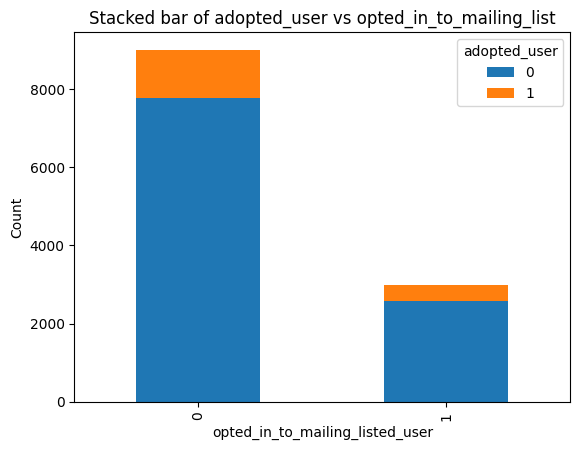

In [126]:
ct = pd.crosstab(users_encoded['opted_in_to_mailing_list'],users_encoded['adopted_user'])
ct.plot(kind='bar', stacked=True)
plt.xlabel('opted_in_to_mailing_listed_user')
plt.ylabel('Count')
plt.title('Stacked bar of adopted_user vs opted_in_to_mailing_list')
plt.show()

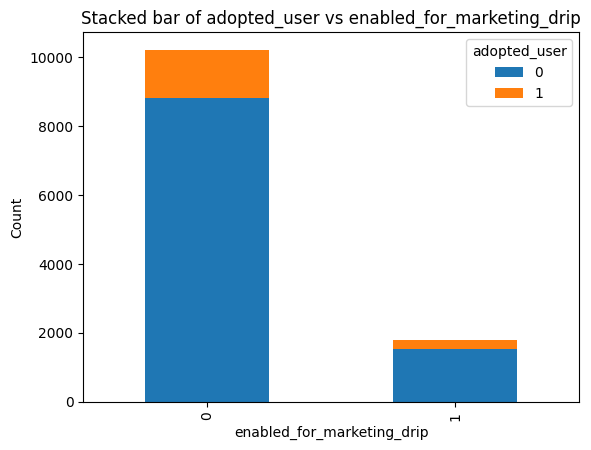

In [127]:
ct = pd.crosstab(users_encoded['enabled_for_marketing_drip'],users_encoded['adopted_user'],)
ct.plot(kind='bar', stacked=True)
plt.xlabel('enabled_for_marketing_drip')
plt.ylabel('Count')
plt.title('Stacked bar of adopted_user vs enabled_for_marketing_drip')
plt.show()

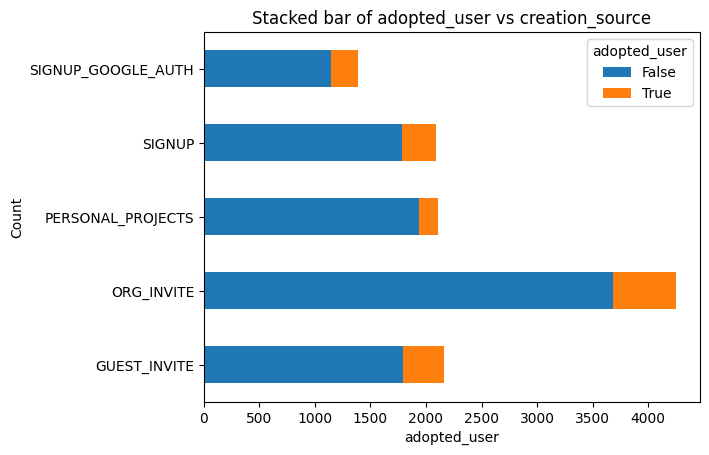

In [128]:
ct = pd.crosstab(users['creation_source'],users['adopted_user'])
ct.plot(kind='barh', stacked=True)
plt.xlabel('adopted_user')
plt.ylabel('Count')
plt.title('Stacked bar of adopted_user vs creation_source')
plt.show()

In [131]:
# Get feature importances from RandomForest
importances = forest.feature_importances_ 

# Get feature names 
feature_names = X_train.columns

# Create a dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(importance_df.head(10))  # Top 10 features

                      feature  importance
0    opted_in_to_mailing_list    0.556569
1  enabled_for_marketing_drip    0.443431


### Summary 
Based on these models, the best predictors of whether a user will adopt the product are 1) did they sign up for a personal project? and 2) did they opt into the mailing list? 

However, due to major class imbalances, these models are best at predicting who won't adopt the product. They aren't very good at predicting who will adopt the product. 

The truth is, the percent of adoptees under the given definition is very low (13.8%). In this case, I suggest relaxing/expanding the definition for adoption to have a more inclusive target. I suspect limiting adoptees to only the users who logged in 3 times a week is actually missing users who are active on the platform at other frequencies. Perhaps someone logs in 2 of 7 days with a login compared to 3/7. Or maybe a user didn't log in 3 times in a week, but they did log in once a week for an entire month. The combinations are endless, and it is acceptable to tweak arbitrary definitions to meet your users where they are.